In [1]:
import os
os.chdir('/home/pz/Documents/model_discrepancy/JAX/burgers')

In [2]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import random
from jax import jit, vmap, value_and_grad, lax
from jax.tree_util import tree_map
import time
from functools import partial
import matplotlib.pyplot as plt
import jax.scipy.stats as stats
import argparse
import pandas as pd
import seaborn as sns
import optax
from flax import linen as nn
from functools import partial
import pickle
import flax
from datetime import date
from jax import checkpoint as remat
from ml_collections import config_dict
import functools
from scipy.stats import gaussian_kde
from flax.training import checkpoints
import pickle
from fno import *
from mlp import *
from utils import *
from data_generation import *
from langevin_FNO import *
from constant_FNO_supervised import *
from losses_FNO import *

rng_key = jax.random.key(int(date.today().strftime("%Y%m%d")))
cfg = load_config("config_FNO_supervised.yml")

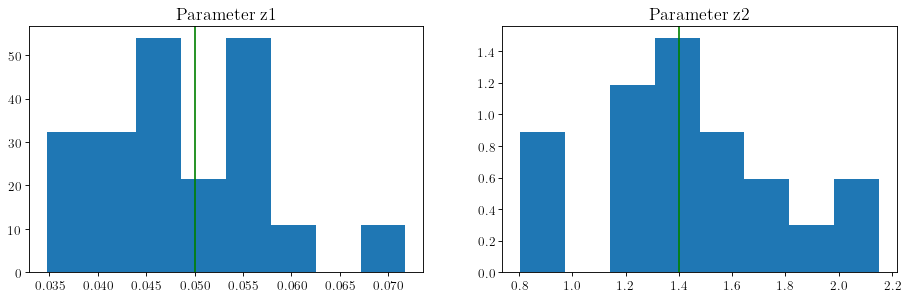

In [ ]:
rng_key = jax.random.key(cfg.data_systems.rng_key)
key, rng_key = jax.random.split(rng_key,2)
parameter_matrix = np.load("/home/pz/Documents/model_discrepancy/JAX/burgers/wandb/latest-run/files/checkpoints/parameters.npy")
systems = vmap_batched_burgers_true(parameter_matrix)
H_mats = np.load("/home/pz/Documents/model_discrepancy/JAX/burgers/wandb/latest-run/files/checkpoints/H_mats.npy")
masks = np.load("/home/pz/Documents/model_discrepancy/JAX/burgers/wandb/latest-run/files/checkpoints/masks.npy")
# parameter_matrix = np.load("/home/pz/Documents/model_discrepancy/JAX/burgers/wandb/good/files/checkpoints/parameters.npy")
# parameter_matrix = generate_parameter_set(rng_key)

plt.figure(figsize=(14, 4), dpi=80)
plt.subplot(1,2,1)
y_k,x_k,_ = plt.hist(jnp.exp(parameter_matrix[:,0]), bins=8,density=True)
plt.axvline(x = cfg.true_parameters.hyperprior_z1, color = 'g')
plt.title("Parameter z1")
plt.subplot(1,2,2)
y_k,x_k,_ = plt.hist(parameter_matrix[:,1], bins=8,density=True)
plt.axvline(x = cfg.true_parameters.hyperprior_z2, color = 'g')
plt.title("Parameter z2")
plt.show()

## Evaluation of alpha and beta

In [5]:
parameter_matrix = np.load("/home/pz/Documents/model_discrepancy/JAX/burgers/wandb/good/files/checkpoints/parameters.npy")
systems = vmap_batched_burgers_true(parameter_matrix)

In [6]:
cfg = load_config("config_FNO_supervised.yml")
restored_FNO_supervised = checkpoints.restore_checkpoint('/home/pz/Documents/model_discrepancy/JAX/burgers/wandb/good/files/checkpoints/current_model_1', target=None, prefix='current_model_')

/home/pz/anaconda3/envs/jax/lib/python3.11/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


In [7]:
fno_model = FNO(cfg, FNO_utils2D)
params_beta_fno_supervised  = restored_FNO_supervised['beta']['params']

alpha_model = MLP(cfg)
params_alpha_fno_supervised = restored_FNO_supervised['alpha']

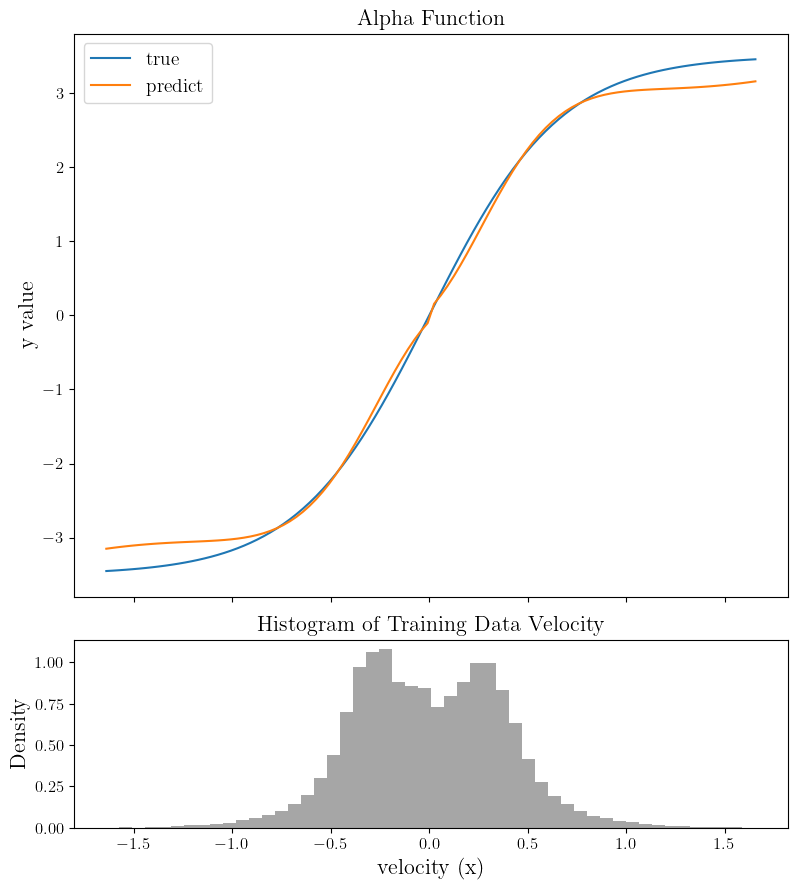

In [8]:
x = jnp.linspace(systems.min(),systems.max(),100).reshape(-1,1)
y_true = nonlinear_function(x)
# y_true = x ** 2
# y_pred_fno_supervised = alpha_model.apply({'params': params_alpha_fno_supervised},x)
out_abs = alpha_model.apply({'params': params_alpha_fno_supervised}, jnp.abs(x))
y_pred_fno_supervised = jnp.sign(x) * out_abs

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(x, y_true, label='true')
ax1.plot(x, y_pred_fno_supervised, label='predict')
ax1.set_title('Alpha Function')
ax1.legend()
ax1.set_ylabel('y value')

ax2.hist(systems.flatten(), bins=50, density=True, alpha=0.7, color='gray')
ax2.set_xlabel('velocity (x)') 
ax2.set_ylabel('Density') 
ax2.set_title('Histogram of Training Data Velocity')

plt.tight_layout()
plt.show()

In [9]:
inputs = jnp.tile(parameter_matrix[:, None, None, :], (1, nt, nx, 1))
inputs = jnp.concatenate([inputs, grid_tiled], axis=-1)

out = fno_model.vmap_z_call({'params': params_beta_fno_supervised}, inputs).squeeze(-1)

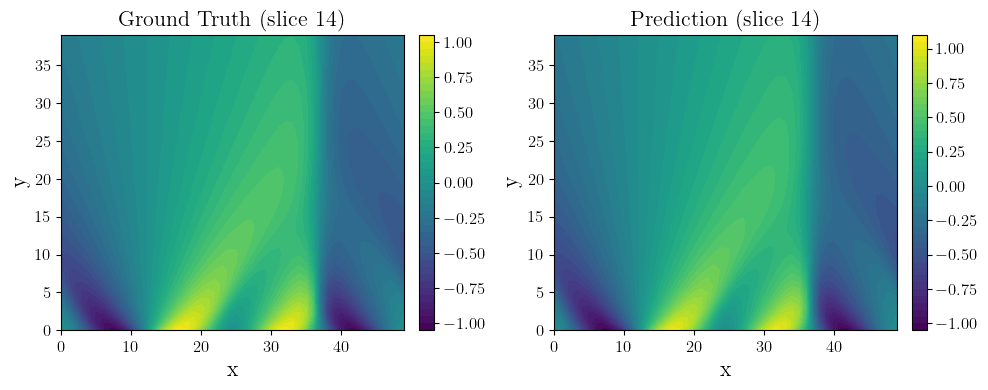

L2 norm: 0.00011367265
1.0491976 1.05095


In [11]:
slice = 14
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

im0 = axs[0].contourf(systems[slice], levels=50, cmap="viridis")
fig.colorbar(im0, ax=axs[0], orientation="vertical", fraction=0.046, pad=0.04)
axs[0].set_title(f"Ground Truth (slice {slice})")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")

im1 = axs[1].contourf(out[slice], levels=50, cmap="viridis")
fig.colorbar(im1, ax=axs[1], orientation="vertical", fraction=0.046, pad=0.04)
axs[1].set_title(f"Prediction (slice {slice})")
axs[1].set_xlabel("x")
axs[1].set_ylabel("y")

plt.tight_layout()
plt.show()

print('L2 norm:', jnp.linalg.norm(out[slice] - systems[slice]) ** 2 / systems[slice].size)
print(systems[slice].max(),out[slice].max())

In [3]:
chain_fno_supervised = np.load("/home/pz/Documents/model_discrepancy/JAX/burgers/wandb/good/files/checkpoints/whole_chain.npy")

In [69]:
chain_num = 1
system_id = 14
true_z1 = parameter_matrix[system_id][0]
true_z2 = parameter_matrix[system_id][1]

In [70]:
theta_z1_list_fno_supervised = jnp.array([path[2*system_id] for path in chain_fno_supervised[chain_num][:10001]])
theta_z2_list_fno_supervised = jnp.array([path[2*system_id+1] for path in chain_fno_supervised[chain_num][:10001]])

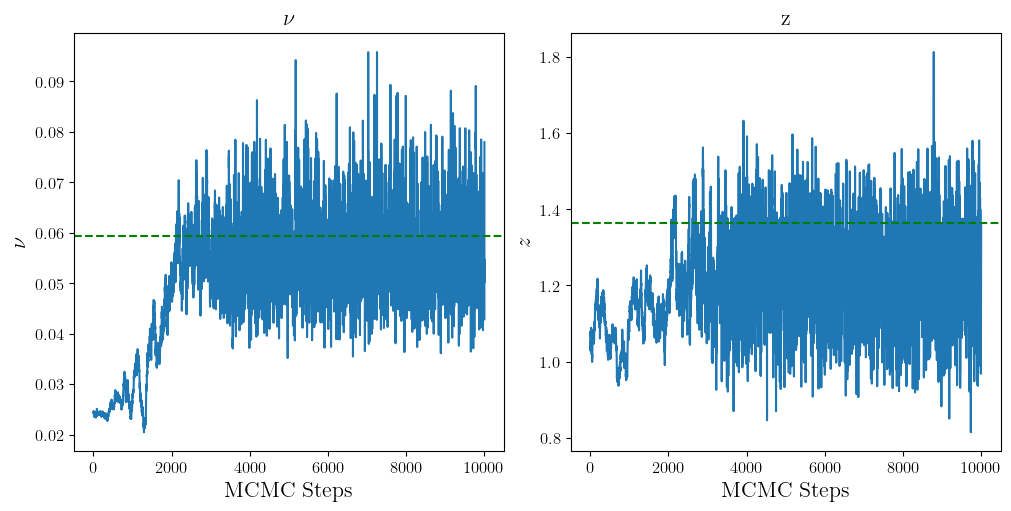

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10,5), constrained_layout=True)

ax = axs[0]
ax.plot(jnp.exp(theta_z1_list_fno_supervised))
ax.axhline(y=jnp.exp(true_z1), color='g', linestyle='--', label="GT $z_1$ = {:.2f}".format(true_z1))
ax.set_title(r"$\nu$") 
ax.set_ylabel(r"$\nu$")
ax.set_xlabel("MCMC Steps")

ax = axs[1]
ax.plot(theta_z2_list_fno_supervised)
ax.axhline(y=true_z2, color='g', linestyle='--', label="GT $z_2$ = {:.2f}".format(true_z2))
ax.set_title('z') 
ax.set_ylabel('$z$')
ax.set_xlabel("MCMC Steps")

plt.show()